# Fixed vs. Optimized Rotation Angles: Trajectory Comparison

Two ECD sequences are optimized to prepare the same Fock state $\ket{m}$ from vacuum:

* **frozen** -- all $N+1$ rotation angles held at $\theta_i = \pi/2$, so only the phases
  $\phi_i$ and displacements $\beta_i$ are free ($3N+1$ parameters);
* **free** -- the angles optimized too ($4N+2$ parameters), via
  `optimize_gate_sequence`.

The Wigner function of the cavity is then plotted after each ECD gate, one row per
optimization, so the two preparation trajectories sit directly above one another.

Two things to know before reading the figures, both checked explicitly below.

**Phase-space orientation is a free gauge.** Fock states are invariant under
$e^{i\chi \hat n}$, so sending every $\beta_i \to \beta_i e^{i\chi}$ rotates the entire
trajectory in phase space and leaves the fidelity *exactly* unchanged -- the circuit
becomes $e^{i\chi \hat n} U e^{-i\chi \hat n}$, and $e^{-i\chi \hat n}\ket{0} = \ket{0}$.
So the two rows can look rotated relative to each other with zero physical difference.
The trajectories are put in a common gauge ($\beta_1$ real and positive) before plotting,
and $P(n)$ -- which is rotation-invariant -- is compared separately as the check that
survives the gauge.

**`plot_wigner` autoscales each panel.** It sets its diverging norm from
`wmax = |W|.max()` of the panel it is given, so a faint frame and a sharply peaked one
both come out fully saturated and amplitudes are *not* comparable across the grid. The
first figure keeps that behaviour, since it is how these are usually plotted; a second
figure repeats it on one shared color scale, which is what the comparison actually needs.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from IPython.display import Math, display

import jax
import jaxquantum as jqt

jax.config.update("jax_enable_x64", True)

from gkp_optimal_control.ecd_symbolic import (
    bloch_axis,
    ecd_propagate,
    ecd_sequence_spec,
    effective_hamiltonian,
    optimize_ecd_fixed_theta,
)
from gkp_optimal_control.gate_optimization import (
    GateBounds,
    OptimizerConfig,
    optimize_gate_sequence,
    sequence_history,
)
from gkp_optimal_control.plotting import plot_wigner, set_plot_style
from gkp_optimal_control.utils import compute_wigner, to_qarray

set_plot_style()
print(f"JAX devices: {jax.devices()}")

JAX devices: [CpuDevice(id=0)]


## Configuration

In [2]:
fock_target = 2               # prepare |m>
n_gates = 5                   # N, the number of ECDs
n_fock = 24                   # optimization truncation
n_fock_plot = 40              # headroom for the Wigner grids
theta_fixed = np.pi / 2       # frozen rotation angle

vac = jqt.basis(n_fock, 0)
target = jqt.basis(n_fock, fock_target)

# soft penalties, shared by both runs so the comparison is apples to apples
penalty_kw = dict(max_disp=4.0, max_disp_weight=1.0, n_leak=6, leakage_weight=1.0)
bounds = GateBounds(**penalty_kw)
optimizer = OptimizerConfig(
    n_seeds=32,
    n_adam_iters=2000,
    peak_lr=0.02,
    init_disp_scale=0.8,
    polish=True,
    seed=0,
)

# plotting
pair, bound, grid = 0, 4.0, 120

print(f"|0> -> |{fock_target}> with N = {n_gates} ECDs")
print(f"frozen: {3 * n_gates + 1} parameters   free: {4 * n_gates + 2} parameters")

|0> -> |2> with N = 5 ECDs
frozen: 16 parameters   free: 22 parameters


## The two optimizations

In [3]:
result = optimize_ecd_fixed_theta(
    n_gates,
    n_fock,
    fock_target,
    theta=theta_fixed,
    n_seeds=64,
    seed=0,
    init_disp_scale=0.8,
    **penalty_kw,
)

gate set        : ecd (theta frozen)
n_gates         : 5
theta_i         : 0.500000 pi  (all 6)
n_params        : 16 free of 22 (6 frozen)
fidelity        : 0.990432
infidelity      : 9.568e-03
loss            : +9.567766e-03
leakage         : 1.970e-09
peak |beta|     : 1.557
best seed       : 13 of 64
seed F spread   : 0.4090 .. 0.9904


In [4]:
result_free = optimize_gate_sequence(
    "ecd",
    n_gates,
    vac,
    target,
    n_fock=n_fock,
    qubit_target="ground",
    disp_method="expm",
    loss_type="log_infidelity",
    bounds=bounds,
    optimizer=optimizer,
    verbose=False,
)

thetas = np.asarray(result.params["thetas"])
phis = np.asarray(result.params["phis"])
betas = np.asarray(result.params["betas"])

thetas_free = np.asarray(result_free.params["thetas"])
phis_free = np.asarray(result_free.params["phis"])
betas_free = np.asarray(result_free.params["betas"])

print(f"theta_i/pi, frozen : {np.round(thetas / np.pi, 5)}")
print(f"theta_i/pi, free   : {np.round(thetas_free / np.pi, 5)}")
print()
print(f"F, theta = pi/2    : {result.fidelity:.9f}   (1 - F = {1 - result.fidelity:.3e})")
print(f"F, theta free      : {result_free.fidelity:.9f}   (1 - F = {1 - result_free.fidelity:.3e})")
print(f"the angles are worth : {result_free.fidelity - result.fidelity:+.3e} in fidelity")
print()
print(f"|beta|, frozen     : {np.round(np.abs(betas), 4)}")
print(f"|beta|, free       : {np.round(np.abs(betas_free), 4)}")

theta_i/pi, frozen : [0.5 0.5 0.5 0.5 0.5 0.5]
theta_i/pi, free   : [-0.5      0.34498  1.2991   0.37256  1.42248  0.5    ]

F, theta = pi/2    : 0.990432236   (1 - F = 9.568e-03)
F, theta free      : 0.998753759   (1 - F = 1.246e-03)
the angles are worth : +8.322e-03 in fidelity

|beta|, frozen     : [1.1965 0.8917 1.557  0.7805 0.4522]
|beta|, free       : [1.3275 0.9113 1.3612 0.6696 0.4124]


## Trajectories

`ecd_propagate` is the NumPy mirror of the ECD circuit, and it is used here rather than
`sequence_history` for one reason: it takes $(\theta, \phi, \beta)$ directly, so the gauge
rotation $\beta_i \to \beta_i e^{i\chi}$ can be applied before propagating. It is checked
against `sequence_history` below so the substitution is not taken on faith.

The history layout is
`[psi_0, after R_1, after ECD_1, after R_2, after ECD_2, ...]`, so the frames right after
each ECD are the **even** indices $2, 4, \ldots, 2N$. Note that a qubit rotation cannot
change the cavity's reduced state at all: it acts as $U_{\rm qubit} \otimes I$, and
$\sum_q (U\psi)_q (U\psi)_q^\dagger = \sum_q \psi_q \psi_q^\dagger$ by unitarity. So the
post-ECD and post-rotation frames give identical Wigner functions, and the choice of index
within a layer is immaterial.

In [5]:
def cavity_dm(frame):
    # trace the qubit out of an ECD block state -> cavity density matrix
    f = np.asarray(frame)
    rho = np.outer(f[0], f[0].conj()) + np.outer(f[1], f[1].conj())
    return rho / np.real(np.trace(rho))


def trajectory(thetas, phis, betas, n_fock_out, align=True):
    # Cavity density matrix right after each ECD gate.
    #
    # With align=True every beta is rotated by a common phase so that beta_1 is
    # real and positive. That is a gauge choice, not a fit: it maps the circuit
    # to exp(i chi n) U exp(-i chi n), which leaves the Fock-state fidelity
    # exactly invariant while rotating the whole trajectory in phase space.
    betas = np.asarray(betas, dtype=complex)
    if align and abs(betas[0]) > 0:
        betas = betas * np.exp(-1j * np.angle(betas[0]))
    _, hist = ecd_propagate(thetas, phis, betas, n_fock_out, return_history=True)
    return [cavity_dm(hist[2 * k]) for k in range(1, len(betas) + 1)]


# cross-check the NumPy mirror against the project's JAX propagator
hist_jax = sequence_history(result, vac)
ref = [cavity_dm(np.asarray(hist_jax[2 * k])[pair]) for k in range(1, n_gates + 1)]
mine = trajectory(thetas, phis, betas, n_fock, align=False)
print("max |rho_numpy - rho_jax| per layer:",
      [f"{np.abs(m - r).max():.1e}" for m, r in zip(mine, ref)])

# the gauge rotation must not move the fidelity
f_aligned = abs(ecd_propagate(
    thetas, phis, betas * np.exp(-1j * np.angle(betas[0])), n_fock
)[0][fock_target]) ** 2
print(f"F before gauge alignment: {result.fidelity:.9f}")
print(f"F after  gauge alignment: {f_aligned:.9f}")

max |rho_numpy - rho_jax| per layer: ['5.6e-16', '7.2e-16', '7.8e-16', '9.6e-16', '1.1e-15']
F before gauge alignment: 0.990432236
F after  gauge alignment: 0.990432236


### Side by side, per-panel scaling

Plotted the usual way, each panel normalized to its own $|W|_{\max}$.

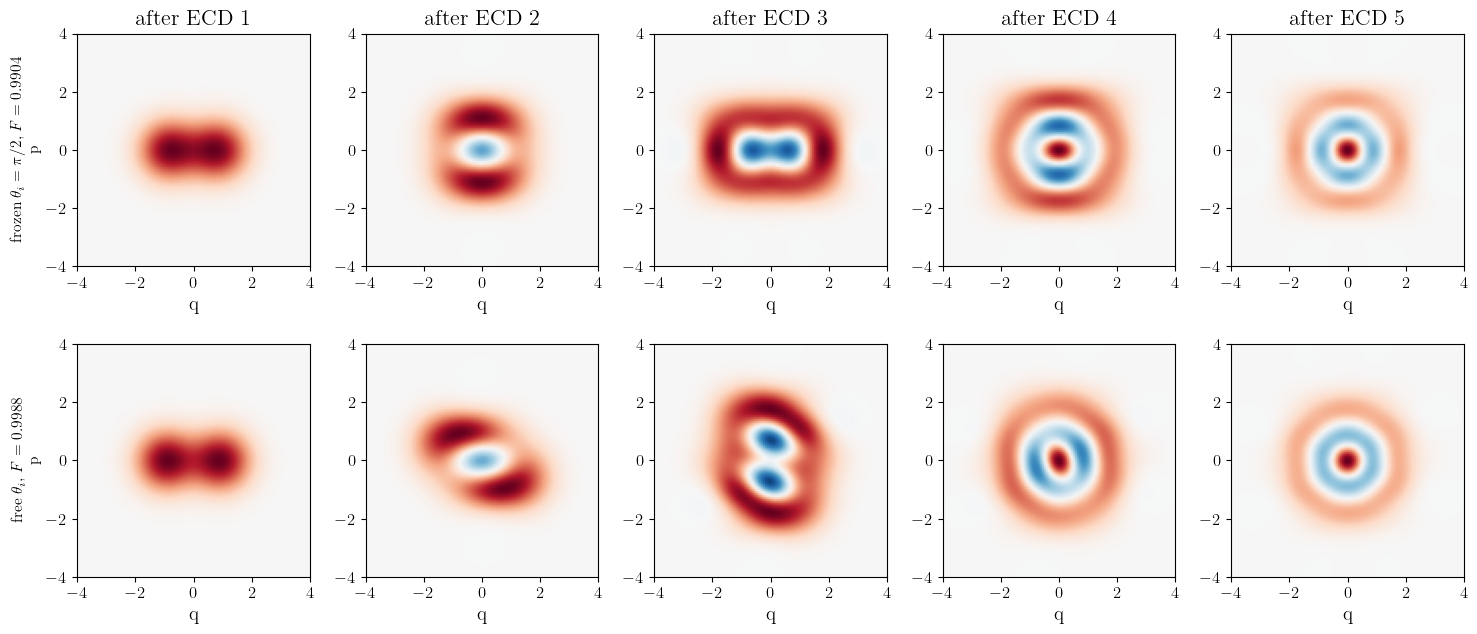

In [6]:
rows = [
    (rf"frozen $\theta_i=\pi/2$, $F={result.fidelity:.4f}$",
     trajectory(thetas, phis, betas, n_fock_plot)),
    (rf"free $\theta_i$, $F={result_free.fidelity:.4f}$",
     trajectory(thetas_free, phis_free, betas_free, n_fock_plot)),
]

fig, axes = plt.subplots(2, n_gates, figsize=(3.0 * n_gates, 6.6))
for r, (row_label, traj) in enumerate(rows):
    for c, rho in enumerate(traj):
        ax = axes[r, c]
        before = set(fig.axes)
        plot_wigner(state=rho, x_bound=bound, y_bound=bound, ax=ax,
                    title=(f"after ECD {c + 1}" if r == 0 else None),
                    grid_points=grid, add_colorbar=False)
        # plot_wigner appends a colorbar axes even when add_colorbar=False;
        # hide the unused strip so it does not eat the panel
        for extra in set(fig.axes) - before:
            extra.set_visible(False)
        if c == 0:
            ax.set_ylabel(f"{row_label}\np", fontsize=11)
        else:
            ax.set_ylabel("")
fig.tight_layout()
plt.show()

### Side by side, one shared color scale

The same trajectories on a single symmetric norm taken from the global
$|W|_{\max}$ over both rows. This is the version to read for amplitude: in the
per-panel figure above, an early low-contrast frame and a sharply peaked late one are
both rendered at full saturation, which flatters the early panels.

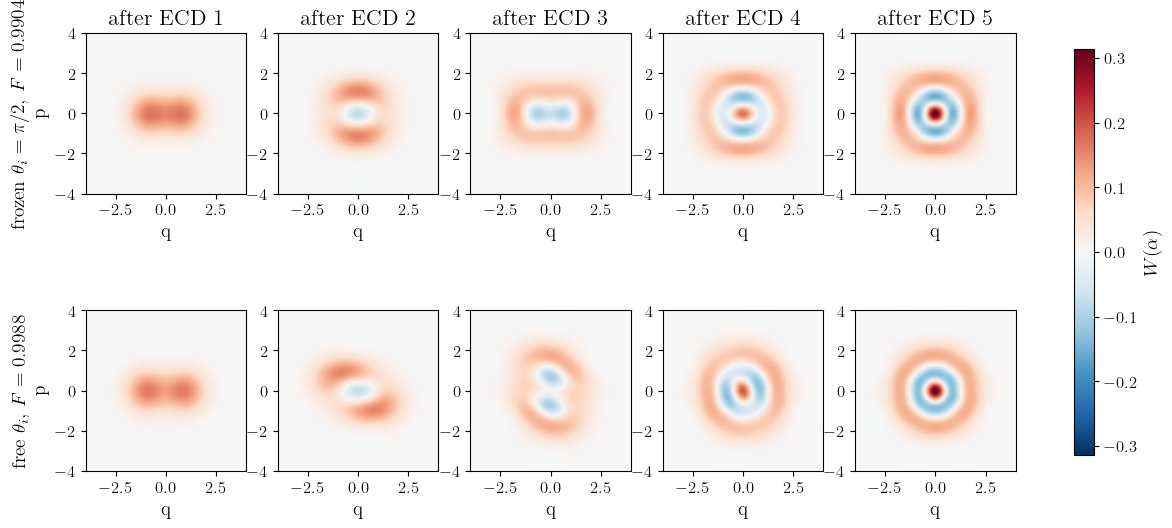

shared scale: |W|max = 0.3145
per-row |W|max: ['0.3144', '0.3145']


In [7]:
import matplotlib.colors as mpl_colors

# precompute every Wigner once, on a common grid
wig_rows = []
for row_label, traj in rows:
    frames = []
    for rho in traj:
        xvec, yvec, w = compute_wigner(rho, bound, bound, grid)
        frames.append(np.real(np.asarray(w)))
    wig_rows.append((row_label, frames))

wmax = max(np.abs(w).max() for _, frames in wig_rows for w in frames)
norm = mpl_colors.TwoSlopeNorm(vmin=-wmax, vcenter=0.0, vmax=wmax)
x_grid, y_grid = np.meshgrid(np.asarray(xvec), np.asarray(yvec))

fig, axes = plt.subplots(2, n_gates, figsize=(3.0 * n_gates, 6.6))
for r, (row_label, frames) in enumerate(wig_rows):
    for c, w in enumerate(frames):
        ax = axes[r, c]
        mesh = ax.pcolormesh(x_grid, y_grid, w, cmap="RdBu_r", norm=norm,
                             shading="gouraud", rasterized=True)
        ax.set_aspect("equal")
        ax.set_xlabel("q")
        if r == 0:
            ax.set_title(f"after ECD {c + 1}")
        ax.set_ylabel(f"{row_label}\np" if c == 0 else "")
fig.colorbar(mesh, ax=axes, shrink=0.8, label=r"$W(\alpha)$")
plt.show()

print(f"shared scale: |W|max = {wmax:.4f}")
print("per-row |W|max:",
      [f"{max(np.abs(w).max() for w in frames):.4f}" for _, frames in wig_rows])

### The gauge-invariant comparison

Whatever the Wigner functions look like, orientation is not physical here. $P(n)$ is
invariant under $e^{i\chi \hat n}$, so comparing the photon-number distributions layer by
layer is what actually says whether the two optimizations found different trajectories or
the same one in a different frame.

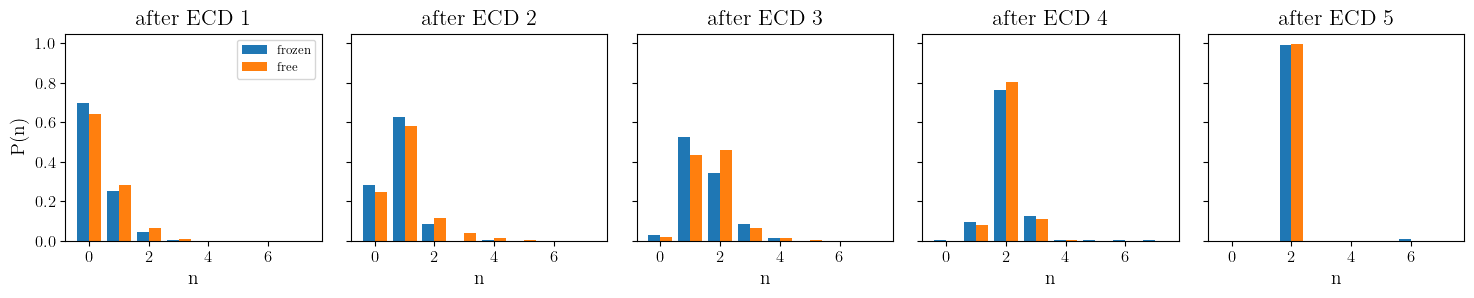

  layer   <n> frozen    <n> free   max |dP(n)|
----------------------------------------------
      1       0.3579      0.4406     5.546e-02
      2       0.8174      0.9925     4.801e-02
      3       1.5374      1.6402     1.156e-01
      4       2.0680      2.0383     4.038e-02
      5       2.0326      1.9999     8.322e-03


In [8]:
max_n = fock_target + 6
width = 0.4
fig, axes = plt.subplots(1, n_gates, figsize=(3.0 * n_gates, 3.2), sharey=True)

pops = {}
for row_label, traj in rows:
    pops[row_label] = [np.real(np.diag(rho))[:max_n] for rho in traj]

labels = list(pops)
for c in range(n_gates):
    ax = np.atleast_1d(axes)[c]
    idx = np.arange(max_n)
    ax.bar(idx - width / 2, pops[labels[0]][c], width, label="frozen")
    ax.bar(idx + width / 2, pops[labels[1]][c], width, label="free")
    ax.set_title(f"after ECD {c + 1}")
    ax.set_xlabel("n")
    if c == 0:
        ax.set_ylabel("P(n)")
        ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"{'layer':>7}  {'<n> frozen':>11}  {'<n> free':>10}  {'max |dP(n)|':>12}")
print("-" * 46)
for c in range(n_gates):
    p_a, p_b = pops[labels[0]][c], pops[labels[1]][c]
    n_a = float(np.dot(np.arange(max_n), p_a))
    n_b = float(np.dot(np.arange(max_n), p_b))
    print(f"{c + 1:>7}  {n_a:>11.4f}  {n_b:>10.4f}  {np.abs(p_a - p_b).max():>12.3e}")

## Effective Hamiltonian via BCH

The trajectories above say *what* each circuit does; an effective Hamiltonian says it in
one operator. Every rotation can be conjugated away, leaving each conditional displacement
as the exponential of a single generator along a rotated Bloch axis,

$$U = \mathcal{Q}\prod_{k=N}^{1}
    \exp\!\Big[\tfrac{\hat n_k\cdot\vec\sigma}{2}
    (\beta_k a^\dagger - \bar\beta_k a)\Big],
  \qquad \hat n_k\cdot\vec\sigma = W_k^\dagger \sigma_z W_k,$$

with $W_k$ the qubit unitary accumulated before the $k$-th ECD. Those exponentials are then
merged by the Baker-Campbell-Hausdorff product formula into

$$U = \mathcal{Q}\, e^{-i H_{\rm eff}},
  \qquad H_{\rm eff} = H^{(1)} + H^{(2)} + H^{(3)} + \cdots$$

graded by powers of the displacement amplitudes: each generator is $O(\beta)$, so a term
with $n$ nested commutators is $O(\beta^{n+1})$.

$\mathcal{Q}$ stays factored out, and not for cosmetic reasons. The grading needs every
merged generator to be $O(\beta)$; a leftover qubit rotation is $O(1)$, and nesting it into
the series would put infinitely many terms at each order in $\beta$. So $H_{\rm eff}$ is
the generator in the frame $\mathcal{Q}$ defines -- the usual toggling-frame effective
Hamiltonian -- and equals $i\log U$ only when `q_is_identity()` is true.

Symbolic field-operator algebra is handled by SymBosonKit. Upstream supplies the
*similarity* transform $e^A B e^{-A}$ but not the *product* formula
$\log(e^A e^B \cdots)$, so `bch_product` builds the latter on its `_normal` primitive by
multiplying truncated exponential series and taking the truncated logarithm -- exact at
each order, and far less error-prone than transcribing high-order BCH coefficients.

### Warm-up: two ECDs, symbolic amplitudes

Small enough to read. $R_y(\pi/2)$ between the two ECDs tips the axis from $\hat z$ to
$-\hat x$, so the generators do not commute.

In [9]:
a1, a2 = sp.symbols("alpha_1 alpha_2", complex=True)
demo = [("ecd", a2), ("ry", sp.pi / 2), ("ecd", a1)]   # written as the product reads

heff_demo = effective_hamiltonian(demo, order=2)

for k, (pauli_m, amp) in enumerate(zip(heff_demo.axes, heff_demo.amplitudes)):
    print(f"  n_{k + 1} = {tuple(bloch_axis(pauli_m))}   alpha_{k + 1} = {amp}")
print(f"  Q proportional to identity? {heff_demo.q_is_identity()}")

for k in (1, 2):
    print(f"\n--- H_eff, order {k} ---")
    for (pauli, mm, nn), coeff in sorted(heff_demo.monomials(k).items()):
        op = ("" if pauli == "1" else f"sigma_{pauli} ")
        op += (f"ad^{mm} " if mm else "") + (f"a^{nn}" if nn else "")
        print(f"   ({sp.simplify(coeff)})  *  {op.strip() or '1'}")

  n_1 = (0, 0, 1)   alpha_1 = alpha_1
  n_2 = (-1, 0, 0)   alpha_2 = alpha_2
  Q proportional to identity? False

--- H_eff, order 1 ---
   (I*conjugate(alpha_2)/2)  *  sigma_x a^1
   (-I*alpha_2/2)  *  sigma_x ad^1
   (-I*conjugate(alpha_1)/2)  *  sigma_z a^1
   (I*alpha_1/2)  *  sigma_z ad^1

--- H_eff, order 2 ---
   (alpha_1*conjugate(alpha_2)/8 + alpha_2*conjugate(alpha_1)/8)  *  sigma_y
   (-conjugate(alpha_1)*conjugate(alpha_2)/4)  *  sigma_y a^2
   (alpha_1*conjugate(alpha_2)/4 + alpha_2*conjugate(alpha_1)/4)  *  sigma_y ad^1 a^1
   (-alpha_1*alpha_2/4)  *  sigma_y ad^2


With $Y(z) = z a^\dagger - \bar z a$ that reads

$$H^{(1)} = \tfrac{i}{2}\big(\sigma_z Y(\alpha_1) - \sigma_x Y(\alpha_2)\big),
  \qquad
  H^{(2)} = -\tfrac{1}{8}\,\sigma_y\,\{Y(\alpha_1), Y(\alpha_2)\}.$$

The second order is the interesting one: $\{Y(\alpha_1), Y(\alpha_2)\}$ is *quadratic* in
$a, a^\dagger$, so two ECDs on non-parallel axes generate a **conditional squeezing** term
$\sigma_y(a^{\dagger 2}, a^\dagger a, a^2)$. It lands on $\sigma_y$ because
$\hat z \times (-\hat x) = -\hat y$.

### The two optimized sequences

`ecd_sequence_spec` lays the optimized parameters out in product order. Passing
`theta_exact=sp.pi/2` for the frozen run keeps those rotations exact instead of picking up
floating-point noise. The axis extraction is not an approximation -- rebuilding
$\mathcal{Q}\prod_k \exp[\ldots]$ reproduces the circuit unitary to $\sim 10^{-15}$.

In [10]:
spec_fix = ecd_sequence_spec(thetas, phis, betas, theta_exact=sp.pi / 2)
spec_free = ecd_sequence_spec(thetas_free, phis_free, betas_free)

for tag, spec in (("frozen", spec_fix), ("free", spec_free)):
    h = effective_hamiltonian(spec, order=1)
    vecs = np.array([[float(c) for c in bloch_axis(ax)] for ax in h.axes])
    print(f"--- {tag}: Bloch axis of each ECD ---")
    for k, v in enumerate(vecs):
        print(f"   n_{k + 1} = ({v[0]:+.4f}, {v[1]:+.4f}, {v[2]:+.4f})")
    print("   pairwise n_i . n_j:")
    for i in range(len(vecs)):
        print("     " + "  ".join(f"{float(np.dot(vecs[i], vecs[j])):+.4f}"
                                  for j in range(len(vecs))))
    print(f"   max |n_z| = {np.abs(vecs[:, 2]).max():.2e}")
    print()

--- frozen: Bloch axis of each ECD ---
   n_1 = (+0.2897, +0.9571, -0.0000)
   n_2 = (+0.9571, -0.2897, +0.0000)
   n_3 = (+0.2897, +0.9571, -0.0000)
   n_4 = (-0.9571, +0.2897, -0.0000)
   n_5 = (+0.2897, +0.9571, +0.0000)
   pairwise n_i . n_j:
     +1.0000  +0.0000  +1.0000  +0.0000  +1.0000
     +0.0000  +1.0000  +0.0000  -1.0000  +0.0000
     +1.0000  +0.0000  +1.0000  -0.0000  +1.0000
     +0.0000  -1.0000  -0.0000  +1.0000  +0.0000
     +1.0000  +0.0000  +1.0000  +0.0000  +1.0000
   max |n_z| = 2.52e-08

--- free: Bloch axis of each ECD ---
   n_1 = (+0.9578, -0.2873, -0.0000)
   n_2 = (-0.7022, -0.7120, +0.0000)
   n_3 = (+0.1605, -0.9870, +0.0000)
   n_4 = (+0.8464, +0.5325, -0.0000)
   n_5 = (+0.7209, -0.6930, -0.0000)
   pairwise n_i . n_j:
     +1.0000  -0.4680  +0.4374  +0.6577  +0.8896
     -0.4680  +1.0000  +0.5901  -0.9735  -0.0128
     +0.4374  +0.5901  +1.0000  -0.3898  +0.7998
     +0.6577  -0.9735  -0.3898  +1.0000  +0.2411
     +0.8896  -0.0128  +0.7998  +0.2411  +

Both optima keep every axis on the **equator**, $n_z \approx 0$. That is a property of the
solutions, not of the ansatz: with random phases, even $\theta_i = \pi/2$ produces tilted
axes for $k \ge 2$. The two differ in how they use the equator -- the frozen run collapses
onto just *two* orthogonal directions that alternate ($\hat n_1 = \hat n_3 = \hat n_5
\perp \hat n_2 = -\hat n_4$, visible as a dot-product matrix of only $0$ and $\pm 1$),
while the free run spreads its axes around the circle.

Equatorial axes force a selection rule. Since $\hat n_i \times \hat n_j \parallel \hat z$
for any two equatorial axes, the order-2 commutator lands entirely on $\sigma_z$, and the
pattern alternates: **odd orders carry $\sigma_x, \sigma_y$; even orders carry $\sigma_z$
and the identity.** The table below uses a threshold relative to each order's largest term,
because the optimizer only converges the equatorial condition to $\sim 10^{-8}$, which sets
the noise floor -- an absolute cutoff would either miss it or swamp it.

In [11]:
def pauli_weights(h, order):
    # sum |coeff| per Pauli at a given order
    wt = {}
    for (pauli, mm, nn), coeff in h.monomials(order).items():
        wt[pauli] = wt.get(pauli, 0.0) + abs(complex(coeff))
    return wt


max_order = 4
heffs = {
    "frozen": effective_hamiltonian(spec_fix, order=max_order),
    "free": effective_hamiltonian(spec_free, order=max_order),
}

for tag, h in heffs.items():
    print(f"--- {tag}: sum |coeff| per Pauli, by order ---")
    print(f"{'order':>6}  {'1':>11}  {'x':>11}  {'y':>11}  {'z':>11}   present")
    for k in range(1, max_order + 1):
        wt = pauli_weights(h, k)
        peak = max(wt.values()) if wt else 0.0
        live = [p for p in ("1", "x", "y", "z") if wt.get(p, 0.0) > 1e-4 * peak]
        print(f"{k:>6}  " + "  ".join(f"{wt.get(p, 0.0):11.3e}"
                                      for p in ("1", "x", "y", "z"))
              + f"   {live}")
    print()

--- frozen: sum |coeff| per Pauli, by order ---
 order            1            x            y            z   present
     1    0.000e+00    9.347e-01    3.068e+00    3.900e-08   ['x', 'y']
     2    2.247e-08    4.095e-08    4.360e-08    1.260e+00   ['z']
     3    1.003e-08    1.486e+00    1.622e+00    6.720e-08   ['x', 'y']
     4    3.284e-01    7.778e-08    8.294e-08    1.385e+00   ['1', 'z']

--- free: sum |coeff| per Pauli, by order ---
 order            1            x            y            z   present
     1    0.000e+00    1.088e+00    2.210e+00    1.607e-15   ['x', 'y']
     2    1.420e-01    3.864e-15    1.767e-15    2.378e+00   ['1', 'z']
     3    8.332e-16    1.188e+00    3.499e+00    2.001e-15   ['x', 'y']
     4    1.508e+00    3.517e-15    1.543e-15    1.975e+00   ['1', 'z']



### How far the truncation can be trusted

Successive ECDs sit on non-parallel axes, so the algebra does not close and the series is
**asymptotic**, not convergent for arbitrary amplitude. Where to stop is therefore an
empirical question. `convergence` answers it by comparing
$e^{-iH_{\rm eff}}\ket{g,0}$ against the exact ECD product, scanning a scale factor applied
to every $\beta$ so the crossover for *this* circuit geometry is visible.

The diagnostic is deliberately state-based. Operator-norm error is misleading here:
$H_{\rm eff}$ carries $a^{\dagger m}a^n$ terms whose matrix elements grow with the
truncation, so `max|exp(-iH) - U|` is dominated by Fock levels the state never visits and
reports failure even where the physics is fine.

In [12]:
scales = (0.1, 0.2, 0.35, 0.5, 0.75, 1.0)
specs = {"frozen": (thetas, phis, betas, sp.pi / 2),
         "free": (thetas_free, phis_free, betas_free, None)}

for tag, (th, ph, be, texact) in specs.items():
    print(f"--- {tag}: || exp(-i H_eff^(k)) |g,0>  -  U|g,0> || ---")
    print(f"{'scale':>6}  {'max|beta|':>10}  "
          + "".join(f"{'k=' + str(k):>11}" for k in range(1, max_order + 1)))
    print("-" * 62)
    for s in scales:
        h = effective_hamiltonian(
            ecd_sequence_spec(th, ph, np.asarray(be) * s, theta_exact=texact),
            order=max_order,
        )
        conv = h.convergence({}, n_fock_plot)
        print(f"{s:6.2f}  {np.abs(np.asarray(be) * s).max():10.4f}  "
              + "".join(f"{conv[k]:11.2e}" for k in range(1, max_order + 1)))
    print()

--- frozen: || exp(-i H_eff^(k)) |g,0>  -  U|g,0> || ---
 scale   max|beta|          k=1        k=2        k=3        k=4
--------------------------------------------------------------
  0.10      0.1557     9.02e-03   1.29e-03   1.25e-04   2.94e-05
  0.20      0.3114     3.72e-02   1.06e-02   2.25e-03   9.55e-04
  0.35      0.5449     1.22e-01   6.07e-02   2.50e-02   1.62e-02
  0.50      0.7785     2.63e-01   1.84e-01   1.16e-01   9.61e-02
  0.75      1.1677     6.16e-01   5.93e-01   5.72e-01   5.65e-01
  1.00      1.5570     1.03e+00   1.09e+00   1.16e+00   7.21e-01

--- free: || exp(-i H_eff^(k)) |g,0>  -  U|g,0> || ---
 scale   max|beta|          k=1        k=2        k=3        k=4
--------------------------------------------------------------
  0.10      0.1361     1.59e-02   1.40e-03   1.43e-04   1.58e-05
  0.20      0.2722     6.40e-02   1.25e-02   2.56e-03   5.82e-04
  0.35      0.4764     1.96e-01   8.02e-02   2.83e-02   1.18e-02
  0.50      0.6806     3.96e-01   2.55e-01   1

Each order buys close to a decade while $\max|\beta| \lesssim 0.5$, and the series stops
improving entirely by $\max|\beta| \approx 1.2$. Both optimized sequences sit at
$\max|\beta| \approx 1.4$ to $1.6$, i.e. **past** the useful range -- at scale $1.0$ the
error is order unity and adding orders does not help. So the $H_{\rm eff}$ printed above is
a correct order-by-order expansion and a fair description of the circuit's *structure*
(which Paulis, which operator content, the conditional-squeezing term), but it is not a
quantitative stand-in for these particular circuits.

If you want an $H_{\rm eff}$ that is quantitative, the lever is amplitude rather than
order: re-optimize with `max_disp` around $0.5$ and more ECDs, trading gate count for a
generator that actually converges.

## Reading the comparison

The fidelity difference printed at the top is the only number that settles whether the
angles earned their keep. The figures say *how* the two solutions differ, and the $P(n)$
table says whether they differ at all beyond a phase-space rotation: if `max |dP(n)|` is
at the $10^{-16}$ level in every layer, the two runs found the same trajectory in
different gauges, and the visual difference between the Wigner rows is nothing but
orientation.

Both rows show the qubit-*traced* cavity state, which is the honest thing to plot mid-
sequence but is not the prepared state at the end: the figure of merit is the $\ket{g}$
block alone, and the two differ by exactly the residual entanglement. At
$1 - F \sim 10^{-2}$ the final traced panel carries visible weight that the projected
state does not. Use `to_qarray(result.final_ket()).unit()` and
`result_free.final_qarray()` for the prepared states themselves.